In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
import joblib
import ipywidgets as widgets
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

In [21]:
# Load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [22]:
# Basic dataset inspection
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())
print("\nDataset Info:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (7043, 21)

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-

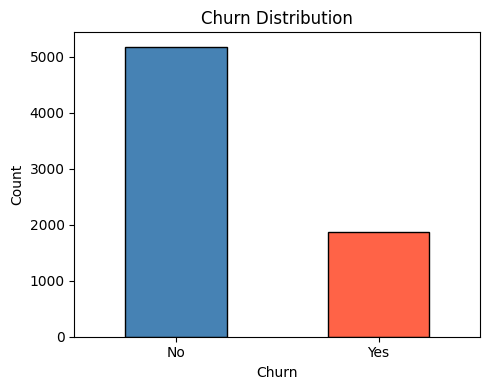

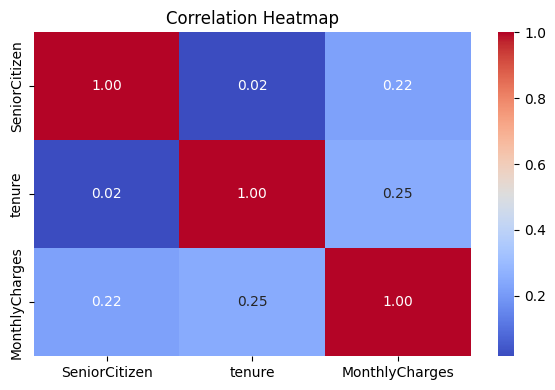

In [23]:
# Class Distribution Chart
plt.figure(figsize=(5, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Correlation Heatmap (numeric columns only)
plt.figure(figsize=(6, 4))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [24]:
# Remove customerID (not useful for prediction)
df.drop(columns=['customerID'], inplace=True)

# Convert TotalCharges to numeric (contains spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Label Encode target column
le = LabelEncoder()
df['Churn'] = le.fit_transform(df['Churn'])

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

# One-Hot Encode categorical features
preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [25]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (5634, 19)
Testing size: (1409, 19)


In [26]:
# Train Logistic Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

In [27]:
# Train Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

In [28]:
# Evaluate both models
def evaluate_model(name, y_test, y_pred):
    print(f"--- {name} ---")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    print()

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)

--- Logistic Regression ---
Accuracy  : 0.8048
Precision : 0.6552
Recall    : 0.5588
F1 Score  : 0.6032

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


--- Random Forest ---
Accuracy  : 0.7779
Precision : 0.6034
Recall    : 0.4759
F1 Score  : 0.5321

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.89      0.85      1035
         Yes       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409




In [29]:
# Model Comparison Table
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy':  [accuracy_score(y_test, y_pred_lr),  accuracy_score(y_test, y_pred_rf)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_rf)],
    'Recall':    [recall_score(y_test, y_pred_lr),    recall_score(y_test, y_pred_rf)],
    'F1 Score':  [f1_score(y_test, y_pred_lr),        f1_score(y_test, y_pred_rf)]
}).set_index('Model').round(4)

display(comparison_df)

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.8048,0.6552,0.5588,0.6032
Random Forest,0.7779,0.6034,0.4759,0.5321


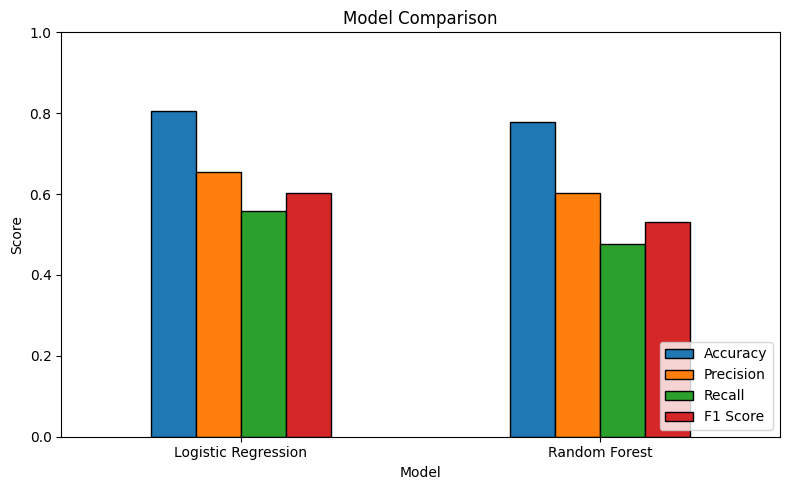

In [30]:
# Model Comparison Bar Chart
comparison_df.plot(kind='bar', figsize=(8, 5), edgecolor='black')
plt.title('Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

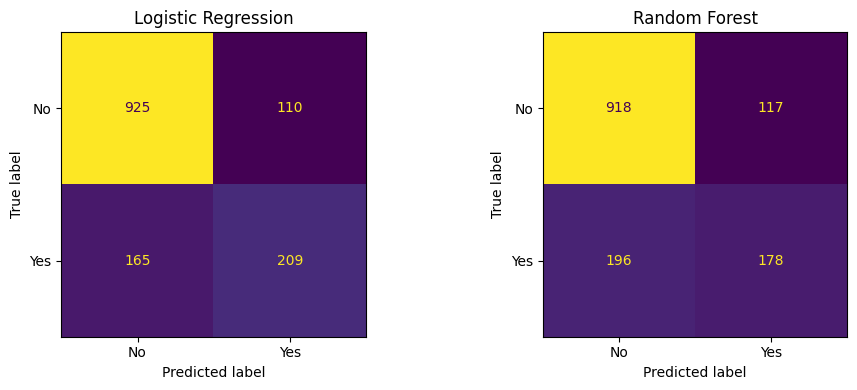

In [31]:
# Confusion Matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, display_labels=le.classes_, ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=le.classes_, ax=axes[1], colorbar=False)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()

In [32]:
# 5-Fold Cross Validation
lr_cv = cross_val_score(lr_pipeline, X, y, cv=5, scoring='accuracy')
rf_cv = cross_val_score(rf_pipeline, X, y, cv=5, scoring='accuracy')

print("Logistic Regression CV Accuracy: {:.4f} ± {:.4f}".format(lr_cv.mean(), lr_cv.std()))
print("Random Forest CV Accuracy     : {:.4f} ± {:.4f}".format(rf_cv.mean(), rf_cv.std()))

Logistic Regression CV Accuracy: 0.8036 ± 0.0074
Random Forest CV Accuracy     : 0.7876 ± 0.0120


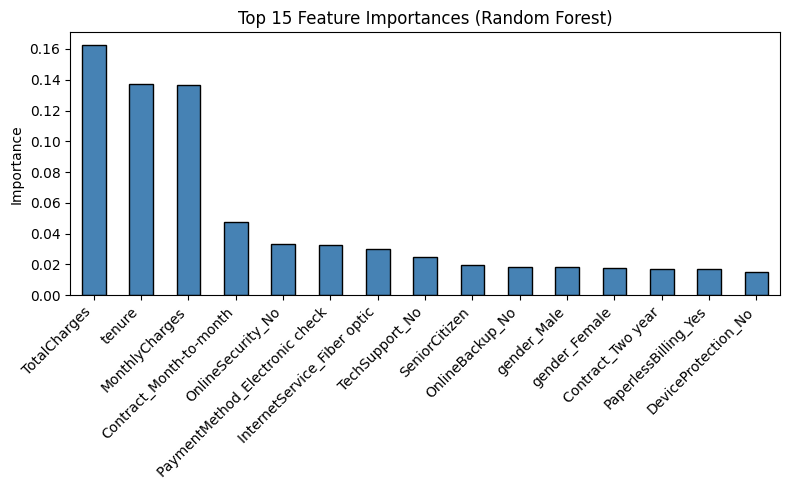

In [33]:
# Feature Importance using Random Forest
rf_model = rf_pipeline.named_steps['classifier']
ohe_cols = rf_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_cols)
feature_names = num_cols + list(ohe_cols)

importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)[:15]

plt.figure(figsize=(8, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [34]:
# Automatically select best model based on accuracy
lr_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)

if rf_acc >= lr_acc:
    best_model = rf_pipeline
    best_model_name = "Random Forest"
else:
    best_model = lr_pipeline
    best_model_name = "Logistic Regression"

print(f"Best Model: {best_model_name} (Accuracy: {max(lr_acc, rf_acc):.4f})")

Best Model: Logistic Regression (Accuracy: 0.8048)


In [35]:
# Save model, preprocessor, and label encoder
joblib.dump(best_model, 'churn_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Saved: churn_model.pkl, preprocessor.pkl, label_encoder.pkl")

Saved: churn_model.pkl, preprocessor.pkl, label_encoder.pkl


In [36]:
# Prediction function
def predict_customer(customer_dict):
    input_df = pd.DataFrame([customer_dict])
    prediction = best_model.predict(input_df)[0]
    return le.inverse_transform([prediction])[0]

In [37]:
# Test with one realistic sample customer
sample_customer = {
    'gender': 'Male',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 12,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 55.0,
    'TotalCharges': 660.0
}

result = predict_customer(sample_customer)
print(f"Prediction: Customer likely to {'Churn' if result == 'Yes' else 'Stay'}")

Prediction: Customer likely to Stay


In [38]:
# Interactive Prediction UI using ipywidgets
gender = widgets.Dropdown(options=['Male', 'Female'], description='Gender:')
senior = widgets.Dropdown(options=[0, 1], description='Senior:')
partner = widgets.Dropdown(options=['Yes', 'No'], description='Partner:')
dependents = widgets.Dropdown(options=['Yes', 'No'], description='Dependents:')
tenure = widgets.IntSlider(min=0, max=72, value=12, description='Tenure:')
phone = widgets.Dropdown(options=['Yes', 'No'], description='Phone:')
multilines = widgets.Dropdown(options=['Yes', 'No', 'No phone service'], description='MultiLines:')
internet = widgets.Dropdown(options=['DSL', 'Fiber optic', 'No'], description='Internet:')
security = widgets.Dropdown(options=['Yes', 'No', 'No internet service'], description='OnlineSec:')
backup = widgets.Dropdown(options=['Yes', 'No', 'No internet service'], description='Backup:')
device = widgets.Dropdown(options=['Yes', 'No', 'No internet service'], description='DeviceProt:')
techsupport = widgets.Dropdown(options=['Yes', 'No', 'No internet service'], description='TechSupport:')
streamingtv = widgets.Dropdown(options=['Yes', 'No', 'No internet service'], description='StreamTV:')
streamingmovies = widgets.Dropdown(options=['Yes', 'No', 'No internet service'], description='StreamMovies:')
contract = widgets.Dropdown(options=['Month-to-month', 'One year', 'Two year'], description='Contract:')
paperless = widgets.Dropdown(options=['Yes', 'No'], description='Paperless:')
payment = widgets.Dropdown(options=['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'], description='Payment:')
monthly = widgets.FloatSlider(min=0, max=120, value=55.0, description='Monthly$:')
total = widgets.FloatSlider(min=0, max=9000, value=660.0, description='Total$:')

output = widgets.Output()
button = widgets.Button(description='Predict', button_style='primary')

def on_click(b):
    output.clear_output()
    customer = {
        'gender': gender.value, 'SeniorCitizen': senior.value,
        'Partner': partner.value, 'Dependents': dependents.value,
        'tenure': tenure.value, 'PhoneService': phone.value,
        'MultipleLines': multilines.value, 'InternetService': internet.value,
        'OnlineSecurity': security.value, 'OnlineBackup': backup.value,
        'DeviceProtection': device.value, 'TechSupport': techsupport.value,
        'StreamingTV': streamingtv.value, 'StreamingMovies': streamingmovies.value,
        'Contract': contract.value, 'PaperlessBilling': paperless.value,
        'PaymentMethod': payment.value, 'MonthlyCharges': monthly.value,
        'TotalCharges': total.value
    }
    result = predict_customer(customer)
    with output:
        if result == 'Yes':
            print("  Customer likely to Churn")
        else:
            print("  Customer likely to Stay")

button.on_click(on_click)

display(widgets.VBox([
    widgets.HBox([gender, senior, partner, dependents]),
    widgets.HBox([tenure, phone, multilines, internet]),
    widgets.HBox([security, backup, device, techsupport]),
    widgets.HBox([streamingtv, streamingmovies, contract, paperless]),
    widgets.HBox([payment, monthly, total]),
    button, output
]))